# Exploratory analysis — SisFall

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rokhaya8/fall-detection-lstm/blob/main/notebooks/00_eda_sisfall.ipynb)

Part of [fall-detection-lstm](https://github.com/Rokhaya8/fall-detection-lstm). Paths are set by `BASE_DIR` in the first code cell — adapt it to your Google Drive.

# 1. Configuration & Chargement des Données
Initialisation de l'environnement, configuration des styles graphiques (minimalistes et professionnels) et chargement des signaux bruts.

In [11]:
import warnings
warnings.filterwarnings('ignore')

# Core
import os
import glob
import zipfile
import numpy as np
import pandas as pd
from IPython.display import display

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Connexion Google Drive (à adapter si exécution locale)
from google.colab import drive
drive.mount('/content/drive')

# ── Dossier du projet dans Google Drive (à adapter si besoin) ──
import os
BASE_DIR = '/content/drive/MyDrive/Projet_Parkinson'
os.makedirs(f'{BASE_DIR}/Figures', exist_ok=True)


# ── Configuration Minimaliste ───────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  '#FFFFFF',   # Fond d'image blanc pur
    'axes.facecolor':    '#FFFFFF',   # Fond de graphique blanc pur
    'axes.edgecolor':    '#E0E0E0',   # Bordures grises très douces
    'axes.labelcolor':   '#333333',   # Texte gris foncé
    'axes.titlecolor':   '#111111',   # Titre très foncé
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'text.color':        '#333333',
    'grid.color':        '#F0F0F0',   # Grille très discrète
    'grid.linestyle':    '-',
    'grid.alpha':        0.8,
    'legend.facecolor':  '#FFFFFF',
    'legend.edgecolor':  '#E0E0E0',
    'legend.fontsize':   10,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,       # Minimalisme : pas de bordure haute
    'axes.spines.right': False,       # Minimalisme : pas de bordure droite
})

# ── Couleurs Métiers (Chutes vs Activités Normales) ─────────
FALL_COLOR  = '#D32F2F'   # Rouge vif (Chute / Alerte)
ADL_COLOR   = '#1976D2'   # Bleu (Activité Quotidienne / Normalité)
PALETTE     = [ADL_COLOR, FALL_COLOR]
sns.set_palette(PALETTE)

# ── Chemins & Facteurs de Conversion ─────────────────────────
CHEMIN_BASE = BASE_DIR
DATA_DIR    = f'{CHEMIN_BASE}/Data_Preprocessed'
CHEMIN_PLOTS= f'{CHEMIN_BASE}/Figures'

# Facteurs de conversion vers la force G (données capteurs SisFall)
CF_ACC1 = 32.0 / 8192.0
CF_ACC2 = 16.0 / 16384.0

print("Environnement et style configurés.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environnement et style configurés.


**Chargement et Prétraitement d'Échantillons**

In [22]:
def charger_sisfall_6axes(chemin):
    """
    Lecture d'un fichier SisFall brut.
    Extrait les deux accéléromètres (ignorant le gyroscope) et convertit en force G.
    """
    df = pd.read_csv(chemin, header=None).replace(';', '', regex=True)
    valeurs = df.values.astype(float)

    # Indices : Acc1 (0,1,2), Gyro (3,4,5), Acc2 (6,7,8)
    data = np.hstack((valeurs[:, 0:3] * CF_ACC1, valeurs[:, 6:9] * CF_ACC2))
    return pd.DataFrame(data, columns=['Acc1_X', 'Acc1_Y', 'Acc1_Z', 'Acc2_X', 'Acc2_Y', 'Acc2_Z'])

# 1. Chemins
chemin_zip = f'{BASE_DIR}/Datasets_bruts/SisFall_dataset.zip'
dossier_extraction = '/content/data/SisFall_dataset'

# 2. Décompression automatique (uniquement si ce n'est pas déjà fait)
if not os.path.exists(dossier_extraction):
    print("Extraction de l'archive en cours...")
    with zipfile.ZipFile(chemin_zip, 'r') as zip_ref:
        zip_ref.extractall('/content/data') # On extrait dans le dossier parent
    print("Décompression terminée !")
else:
    print("Les données sont déjà décompressées dans l'environnement.")

# 3. Extraction de la liste des fichiers à partir du dossier décompressé
sisfall_brut_path = dossier_extraction
all_files = []

if os.path.exists(sisfall_brut_path):
    # On cherche tous les .txt dans les sous-dossiers
    all_files = [f for f in glob.glob(f"{sisfall_brut_path}/**/*.txt", recursive=True) if os.path.basename(f).startswith(('D', 'F'))]
    print(f"Nombre total de fichiers '.txt' détectés : {len(all_files):,}")
else:
    print(f"Erreur : Le dossier {sisfall_brut_path} est introuvable après l'extraction.")

Les données sont déjà décompressées dans l'environnement.
Nombre total de fichiers '.txt' détectés : 4,505


# 2. Audit de Qualité & Statistiques Descriptives
Vérification de l'intégrité des données (valeurs manquantes) et de la plausibilité physique (bornes de l'accélération en G).

In [24]:
# Test d'intégrité sur un échantillon
if len(all_files) > 0:
    echantillon = all_files[:100]
    nans_detectes = sum([1 for f in echantillon if charger_sisfall_6axes(f).isnull().values.any()])
    print(f"  Analyses sur échantillon ({len(echantillon)} fichiers) :")
    print(f"  Valeurs manquantes (NaN) détectées : {nans_detectes} fichiers compromis.\n")

    # Plausibilité Physique sur le premier fichier
    df_test = charger_sisfall_6axes(all_files[0])
    print("  Statistiques descriptives (converties en Force G) :")
    stats = df_test.describe().round(3)
    display(stats)

    max_g = df_test.abs().max().max()
    print(f"\n Maximum absolu détecté sur cet échantillon : {max_g:.2f} G")
    if max_g > 16:
        print(" AVERTISSEMENT : Le maximum dépasse les capacités du capteur (16G).")
    else:
        print(" Plausibilité physique respectée.")

  Analyses sur échantillon (100 fichiers) :
  Valeurs manquantes (NaN) détectées : 0 fichiers compromis.

  Statistiques descriptives (converties en Force G) :


,Acc1_X,Acc1_Y,Acc1_Z,Acc2_X,Acc2_Y,Acc2_Z
count,4999.000,4999.000,4999.000,4999.000,4999.000,4999.000
mean,0.056,-1.001,-0.040,-0.026,-0.957,0.115
std,0.115,0.155,0.180,0.111,0.149,0.177
min,-0.441,-1.867,-0.523,-0.518,-1.816,-0.362
25%,-0.012,-1.051,-0.176,-0.097,-1.006,-0.016
50%,0.055,-0.977,0.000,-0.028,-0.931,0.153
75%,0.137,-0.906,0.105,0.053,-0.862,0.257
max,0.512,-0.672,0.445,0.407,-0.642,0.587



 Maximum absolu détecté sur cet échantillon : 1.87 G
 Plausibilité physique respectée.


# 3. Analyse du Déséquilibre des Classes
L'évaluation du rapport entre les Activités de la Vie Quotidienne (ADL) et les Chutes est primordiale pour configurer les hyperparamètres (comme les `class_weights`) de nos futurs réseaux de neurones.

 DISTRIBUTION DES CLASSES
  Fichiers Chutes (F)    : 1,798 (39.9%)
  Fichiers Activités (D) : 2,707 (60.1%)
  Ratio de déséquilibre  : 1 Chute pour ~ 1.51 Activités



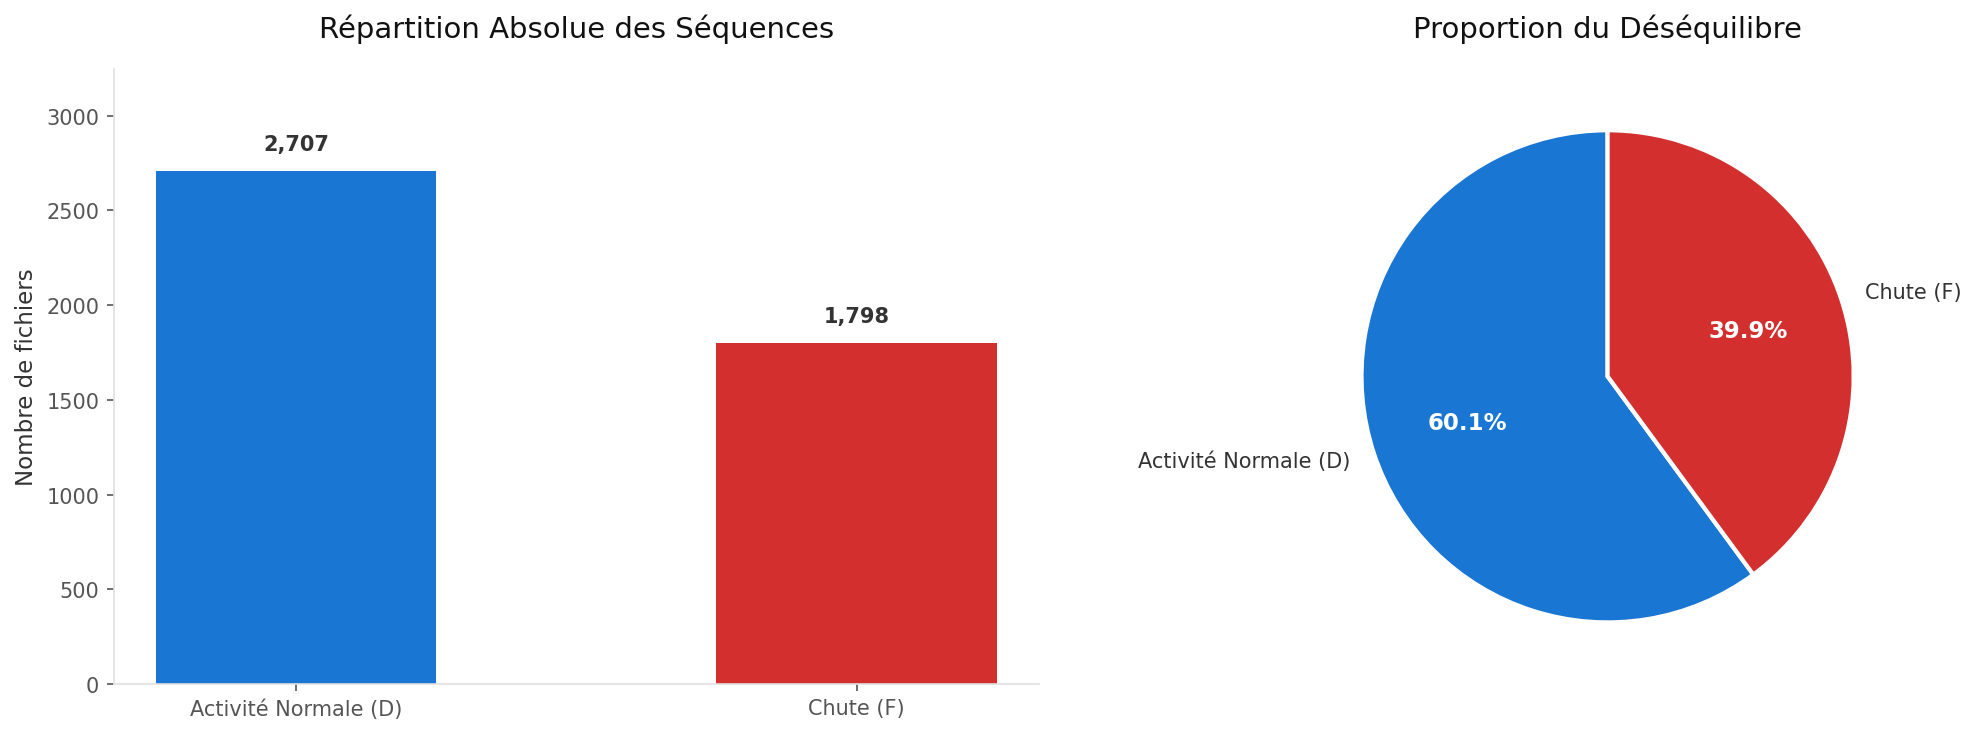

✓ Graphique sauvegardé : /content/drive/MyDrive/Projet_Parkinson/Notebooks/Plots/distribution_classes_sisfall.png


In [19]:
# Variables de comptage
nb_fichiers_chutes = 0
nb_fichiers_activites = 0

if len(all_files) > 0:
    for f in all_files:
        if os.path.basename(f).startswith('F'):
            nb_fichiers_chutes += 1
        elif os.path.basename(f).startswith('D'):
            nb_fichiers_activites += 1

    total = nb_fichiers_chutes + nb_fichiers_activites
    pct_chutes = (nb_fichiers_chutes / total) * 100
    pct_activites = (nb_fichiers_activites / total) * 100

    print("=" * 60)
    print(" DISTRIBUTION DES CLASSES")
    print("=" * 60)
    print(f"  Fichiers Chutes (F)    : {nb_fichiers_chutes:,} ({pct_chutes:.1f}%)")
    print(f"  Fichiers Activités (D) : {nb_fichiers_activites:,} ({pct_activites:.1f}%)")
    print(f"  Ratio de déséquilibre  : 1 Chute pour ~ {(nb_fichiers_activites / nb_fichiers_chutes):.2f} Activités\n")
    # ── Visualisation ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    bars = axes[0].bar(['Activité Normale (D)', 'Chute (F)'],
                       [nb_fichiers_activites, nb_fichiers_chutes],
                       color=PALETTE, width=0.5)
    axes[0].set_title('Répartition Absolue des Séquences', pad=15)
    axes[0].set_ylabel('Nombre de fichiers')

    # Ajout des étiquettes de données
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + (total*0.02),
                 f'{int(height):,}', ha='center', va='bottom', fontweight='bold')
    axes[0].set_ylim(0, max(nb_fichiers_activites, nb_fichiers_chutes) * 1.2)

    # Pie chart
    wedges, texts, autotexts = axes[1].pie(
        [nb_fichiers_activites, nb_fichiers_chutes],
        labels=['Activité Normale (D)', 'Chute (F)'],
        colors=PALETTE,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    plt.setp(autotexts, size=11, weight="bold", color="white")
    axes[1].set_title('Proportion du Déséquilibre', pad=15)

    plt.tight_layout()

    # Sauvegarde
    plot_path_dist = f'{CHEMIN_PLOTS}/distribution_classes_sisfall.png'
    plt.savefig(plot_path_dist, bbox_inches='tight')
    plt.show()
    print(f"✓ Graphique sauvegardé : {plot_path_dist}")

# 4. Visualisation des Signatures Temporelles
Comparaison dynamique des signaux d'accélération entre une Activité de la Vie Quotidienne (ADL) et une Chute. L'objectif est d'identifier visuellement la "signature d'impact" (le pic d'accélération soudain) et d'observer le changement de comportement post-chute.

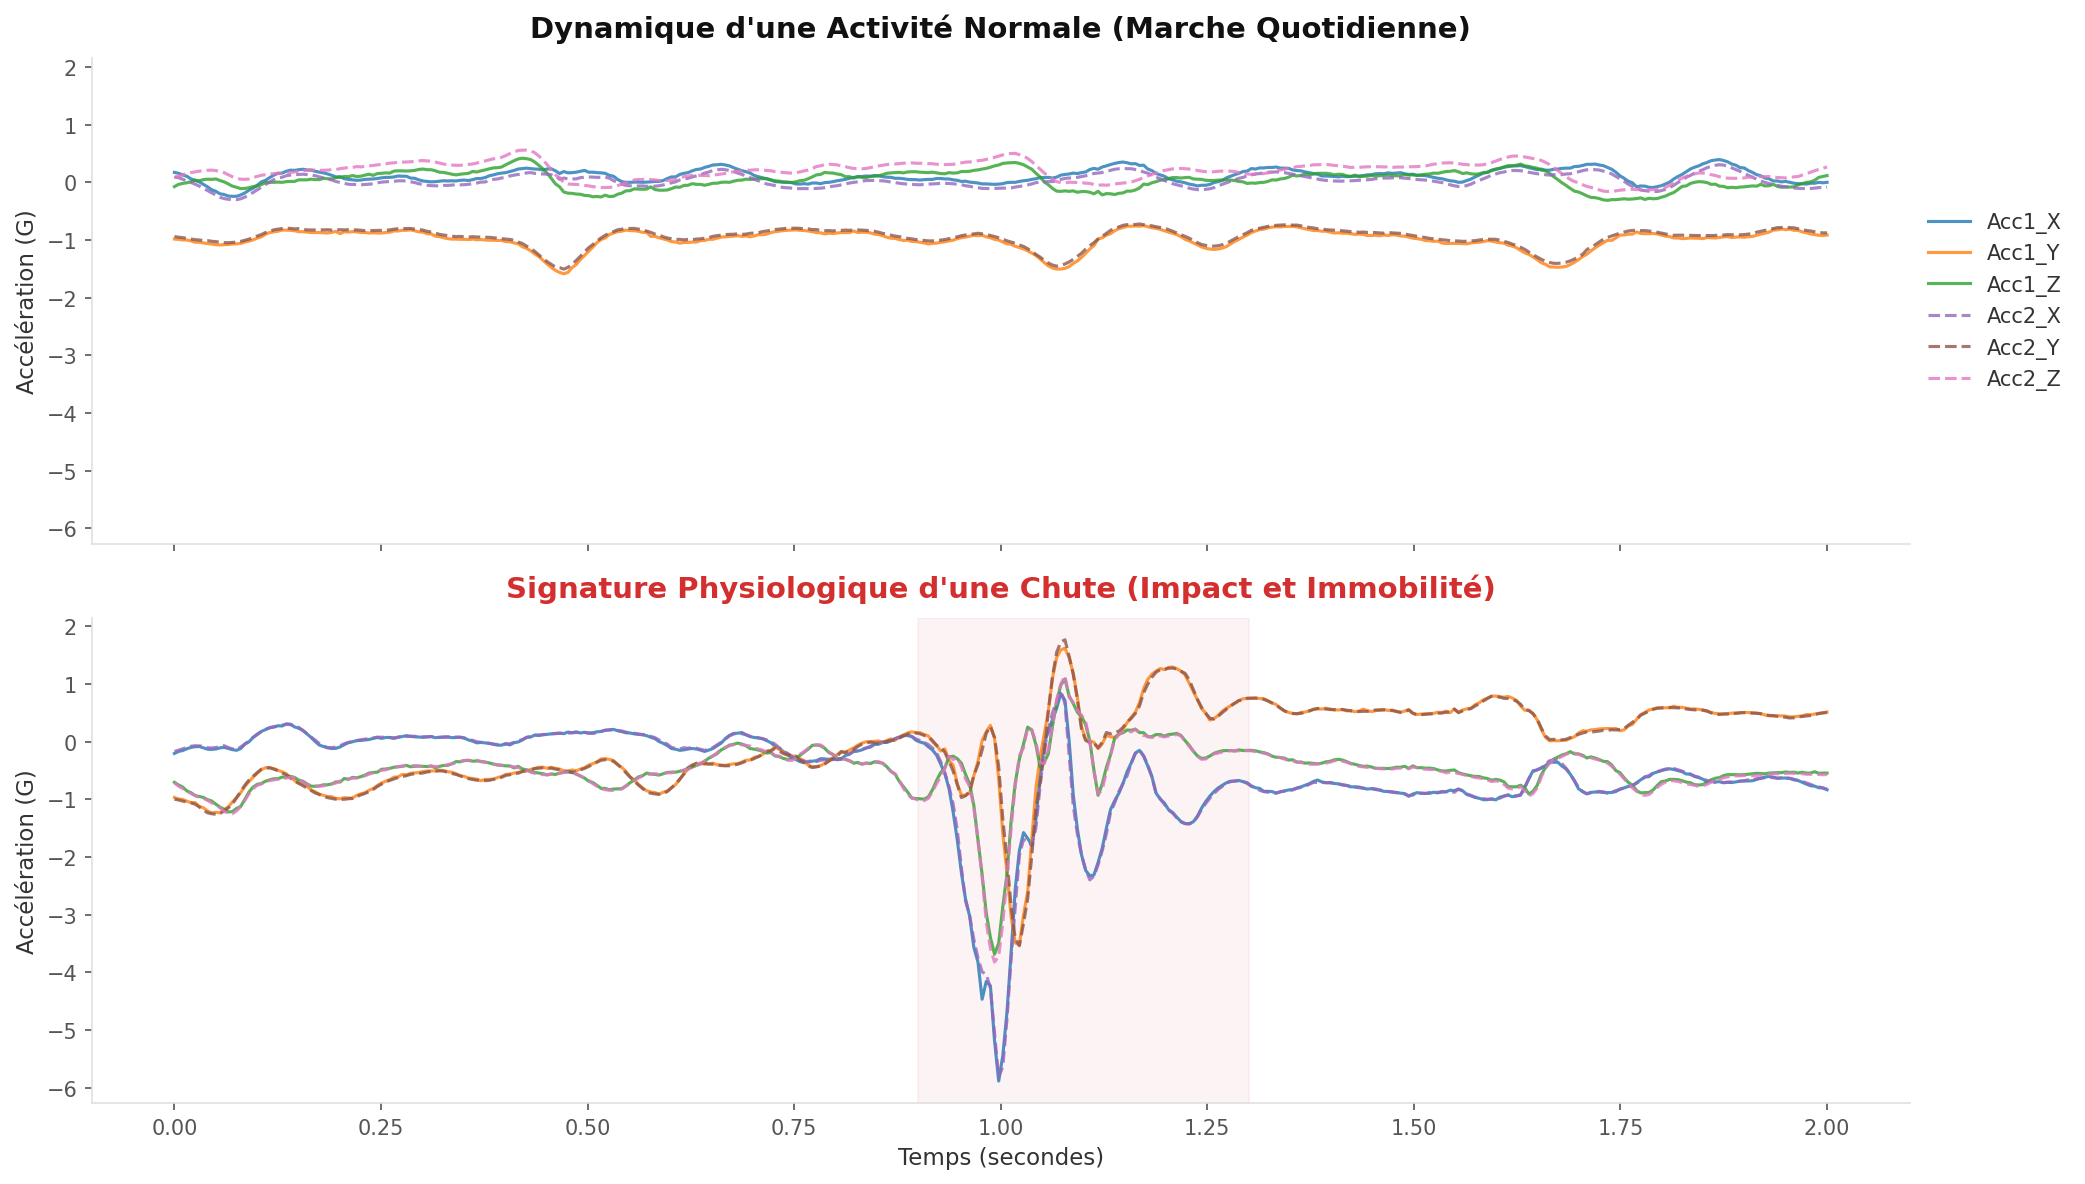

Graphique sauvegardé : /content/drive/MyDrive/Projet_Parkinson/Notebooks/Plots/signatures_temporelles.png


In [26]:
if len(all_files) > 0:
    # Récupération d'un exemple représentatif de chaque classe
    fichier_adl = next(f for f in all_files if os.path.basename(f).startswith('D01'))
    fichier_chute = next(f for f in all_files if os.path.basename(f).startswith('F01'))

    df_adl = charger_sisfall_6axes(fichier_adl)
    df_chute = charger_sisfall_6axes(fichier_chute)

    # Afin d'avoir une visualisation claire, nous nous concentrons sur une fenêtre de 400 échantillons (2 secondes)
    start_idx = 1000
    window = 400

    # S'assurer que le fichier chute contient bien la chute dans cette fenêtre
    # Souvent, le pic d'accélération correspond à l'impact
    peak_idx = df_chute.abs().sum(axis=1).idxmax()
    start_chute = max(0, peak_idx - 200)

    seq_adl = df_adl.iloc[start_idx : start_idx + window]
    seq_chute = df_chute.iloc[start_chute : start_chute + window]

    temps = np.linspace(0, window / 200, window) # Fréquence d'échantillonnage de 200 Hz

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)

    # Palette subtile pour les 6 axes
    axes_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2']

    # --- Tracé ADL ---
    for i, col in enumerate(df_adl.columns):
        ls = '-' if 'Acc1' in col else '--' # Trait continu pour Acc1, pointillé pour Acc2
        axes[0].plot(temps, seq_adl[col], label=col, color=axes_colors[i], linestyle=ls, alpha=0.8, linewidth=1.5)

    axes[0].set_title("Dynamique d'une Activité Normale (Marche Quotidienne)", pad=10, fontweight='bold')
    axes[0].set_ylabel("Accélération (G)")
    axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

    # --- Tracé Chute ---
    for i, col in enumerate(df_chute.columns):
        ls = '-' if 'Acc1' in col else '--'
        axes[1].plot(temps, seq_chute[col], color=axes_colors[i], linestyle=ls, alpha=0.8, linewidth=1.5)

    axes[1].set_title("Signature Physiologique d'une Chute (Impact et Immobilité)", pad=10, fontweight='bold', color=FALL_COLOR)
    axes[1].set_xlabel("Temps (secondes)")
    axes[1].set_ylabel("Accélération (G)")

    # Marquer la zone d'impact
    axes[1].axvspan(0.9, 1.3, color=FALL_COLOR, alpha=0.05, label='Zone d\'impact')

    plt.tight_layout()

    # Sauvegarde
    plot_path_signals = f'{CHEMIN_PLOTS}/signatures_temporelles.png'
    plt.savefig(plot_path_signals, bbox_inches='tight')
    plt.show()
    print(f"Graphique sauvegardé : {plot_path_signals}")

# 5. Analyse Comparative de la Matrice de Corrélation
Cette section évalue la redondance linéaire entre les axes spatiaux des capteurs.
Nous comparons l'indépendance globale des axes sur de longues périodes d'activité (Macro) face à leur forte synchronisation instantanée lors d'un choc ou d'un impact (Micro), justifiant la nécessité des 6 canaux pour la modélisation.

Calcul des matrices de corrélation...


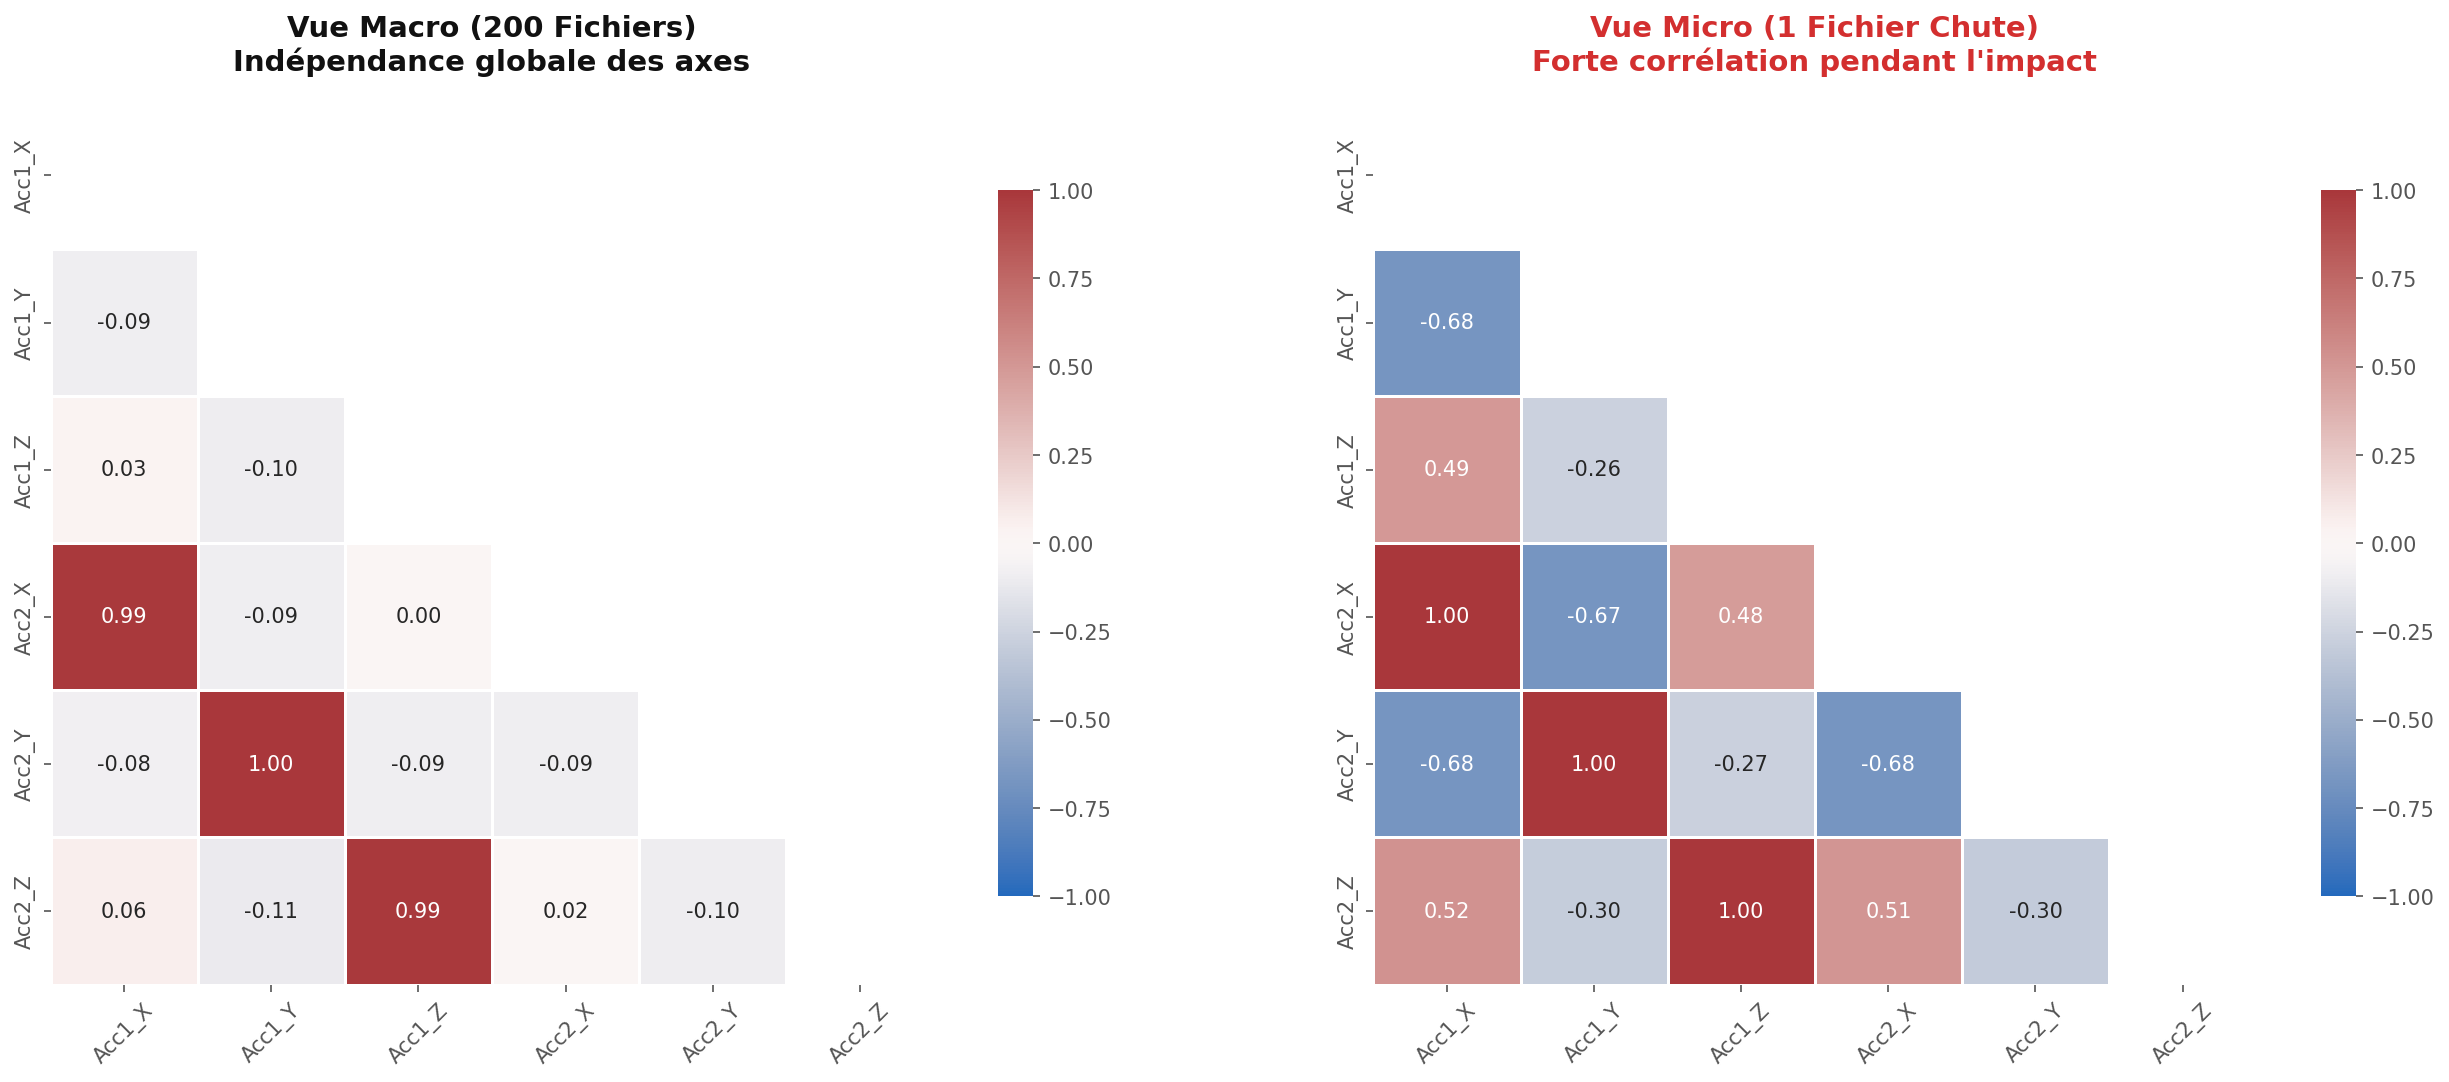

✓ Illustration comparative sauvegardée sous : /content/drive/MyDrive/Projet_Parkinson/Notebooks/Plots/correlation_comparative_sisfall.png


In [38]:
if len(all_files) > 0:
    print("Calcul des matrices de corrélation...")

    # --- 1. Calcul Global (200 fichiers ADL + Chutes) ---
    fichiers_echantillon = all_files[:200]
    list_dfs = [charger_sisfall_6axes(f) for f in fichiers_echantillon]
    df_global = pd.concat(list_dfs, axis=0, ignore_index=True)
    corr_global = df_global.corr()

    # --- 2. Calcul Local (Uniquement 1 Chute violente) ---
    fichier_chute = next(f for f in all_files if os.path.basename(f).startswith('F01'))
    df_locale = charger_sisfall_6axes(fichier_chute)
    corr_locale = df_locale.corr()

    # --- 3. Affichage Comparatif ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    masque_global = np.triu(np.ones_like(corr_global, dtype=bool))
    masque_local = np.triu(np.ones_like(corr_locale, dtype=bool))

    # Matrice 1 : Vue Globale (Indépendance)
    sns.heatmap(corr_global, mask=masque_global, annot=True, fmt=".2f", cmap="vlag",
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5,
                cbar_kws={"shrink": .8}, ax=axes[0])
    axes[0].set_title("Vue Macro (200 Fichiers)\nIndépendance globale des axes", pad=15, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)

    # Matrice 2 : Vue Locale (Synchronisation lors d'un choc)
    sns.heatmap(corr_locale, mask=masque_local, annot=True, fmt=".2f", cmap="vlag",
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5,
                cbar_kws={"shrink": .8}, ax=axes[1])
    axes[1].set_title(f"Vue Micro (1 Fichier Chute)\nForte corrélation pendant l'impact", pad=15, fontweight='bold', color='#D32F2F')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()

    # Sauvegarde
    chemin_enregistrement = f'{CHEMIN_PLOTS}/correlation_comparative_sisfall.png'
    plt.savefig(chemin_enregistrement, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✓ Illustration comparative sauvegardée sous : {chemin_enregistrement}")